# Framingham Heart Study
## Ficha Descriptiva del Proyecto

**Curso**: MCDIA501 - Estadistica Computacional para la Toma de Decisiones  
**Evaluacion**: Formativa 1 | Fase 1  
**Dataset**: Framingham Heart Study (n = 4,238 pacientes, 16 variables)  

| Campo | Detalle |
|---|---|
| **Integrantes** | Renato Villazón - Francisco Santelices - Fabian Castillo |
| **Docente** |  |

---

### Objetivo del notebook

Este notebook corresponde a la **Fase 1** del proyecto: definicion y comprension del problema. El foco esta en:

1. Cargar y explorar la estructura del dataset
2. Clasificar las variables segun su tipo estadistico
3. Identificar relaciones preliminares entre variables


## 1. Configuracion

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency
from statsmodels.stats.proportion import proportion_confint
from pathlib import Path

print('Librerias cargadas correctamente.')
print(f'  Python      {sys.version.split()[0]}')
print(f'  pandas      {pd.__version__}')
print(f'  seaborn     {sns.__version__}')
print(f'  scipy       {scipy.__version__}')

# Configuracion visual
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

Librerias cargadas correctamente.
  Python      3.14.5
  pandas      3.0.3
  seaborn     0.13.2
  scipy       1.18.0


In [2]:
import kagglehub
import shutil
from pathlib import Path

# Descargar dataset
download_path = kagglehub.dataset_download(
    "aasheesh200/framingham-heart-study-dataset"
)

print("Descargado en:", download_path)

# Crear carpeta data
data_dir = Path("../data/raw")
data_dir.mkdir(exist_ok=True)

# Buscar archivos csv descargados
for csv_file in Path(download_path).glob("*.csv"):
    destino = data_dir / csv_file.name
    shutil.copy(csv_file, destino)
    print(f"Copiado: {csv_file.name} -> {destino}")

df = pd.read_csv(data_dir / "framingham.csv")

print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Memoria aproximada: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')


Descargado en: C:\Users\fabia\.cache\kagglehub\datasets\aasheesh200\framingham-heart-study-dataset\versions\1
Copiado: framingham.csv -> ..\data\raw\framingham.csv
Dimensiones: 4,240 filas x 16 columnas
Memoria aproximada: 530.1 KB


In [3]:
# Primeras 5 filas
df.head()


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
# Informacion general del dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


## 2. Calidad de los datos

Se identifican valores faltantes para cada variable. El Framingham Heart Study tiene faltantes **naturales** en algunas variables clinicas, lo que es caracteristico de estudios epidemiologicos reales.

In [5]:
# Conteo y porcentaje de valores faltantes
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)

faltantes = pd.DataFrame({
    'Faltantes': nulos,
    'Porcentaje (%)': pct
}).sort_values('Porcentaje (%)', ascending=False)

print('Variables con valores faltantes:')
display(faltantes[faltantes['Faltantes'] > 0])

print(f'\nTotal de variables sin faltantes: {(nulos == 0).sum()}')
print('\nNota: los faltantes son naturales (no generados artificialmente).')
print('No se requiere aplicar mecanismo MCAR en este dataset.')

Variables con valores faltantes:


,Faltantes,Porcentaje (%)
glucose,388,9.15
education,105,2.48
BPMeds,53,1.25
totChol,50,1.18
cigsPerDay,29,0.68
BMI,19,0.45
heartRate,1,0.02



Total de variables sin faltantes: 9

Nota: los faltantes son naturales (no generados artificialmente).
No se requiere aplicar mecanismo MCAR en este dataset.


In [6]:
# Comparacion: dataset completo vs sin faltantes
# El compañero uso df.dropna() global; aqui documentamos el impacto.
# Decision metodologica: se trabaja con el dataset COMPLETO y se aplica
# .dropna() solo donde cada calculo lo requiera (por variable).

print(f'Registros originales    : {df.shape[0]:,}')
print(f'Registros tras dropna() : {df.dropna().shape[0]:,}')
print(f'Filas eliminadas        : {df.shape[0] - df.dropna().shape[0]}')
print()
print('Decision: se conserva el dataset completo para no perder')
print('informacion. Los calculos usan .dropna() por variable.')


Registros originales    : 4,240
Registros tras dropna() : 3,658
Filas eliminadas        : 582

Decision: se conserva el dataset completo para no perder
informacion. Los calculos usan .dropna() por variable.


## 3. Clasificacion de variables

Cada variable se clasifica segun su **tipo estadistico** y su **rol** en el analisis. Esta clasificacion determina que metodos estadisticos y visualizaciones son validos para cada variable.

| Tipo estadistico | Subtipo | Operaciones validas | Graficos apropiados |
|---|---|---|---|
| Cualitativa nominal | Binaria | Frecuencias, moda | Barras, torta |
| Cualitativa ordinal | Ordenada | Frecuencias, mediana | Barras ordenadas |
| Cuantitativa discreta | Contable | Todas las aritmeticas | Histograma, barras |
| Cuantitativa continua | Medible | Todas las aritmeticas | Histograma, boxplot |

In [7]:
# Clasificacion manual de variables segun tipo estadistico
clasificacion = {
    'Variable': [
        'male', 'age', 'education', 'currentSmoker', 'cigsPerDay',
        'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes',
        'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose',
        'TenYearCHD'
    ],
    'Tipo estadistico': [
        'Cualitativa', 'Cuantitativa', 'Cualitativa', 'Cualitativa', 'Cuantitativa',
        'Cualitativa', 'Cualitativa', 'Cualitativa', 'Cualitativa',
        'Cuantitativa', 'Cuantitativa', 'Cuantitativa', 'Cuantitativa',
        'Cuantitativa', 'Cuantitativa', 'Cualitativa'
    ],
    'Subtipo': [
        'Nominal binaria', 'Discreta', 'Ordinal', 'Nominal binaria', 'Discreta',
        'Nominal binaria', 'Nominal binaria', 'Nominal binaria', 'Nominal binaria',
        'Continua', 'Continua', 'Continua', 'Continua', 'Continua', 'Continua',
        'Nominal binaria'
    ],
    'Faltantes': [
        'No', 'No', 'Si', 'No', 'Si',
        'Si', 'No', 'No', 'No',
        'Si', 'No', 'No', 'Si', 'Si', 'Si',
        'No'
    ],
    'Rol': [
        'Demografica', 'Demografica', 'Demografica', 'Conductual', 'Conductual',
        'Clinica', 'Clinica', 'Clinica', 'Clinica',
        'Clinica', 'Clinica', 'Clinica', 'Clinica', 'Clinica', 'Clinica',
        'Variable objetivo'
    ]
}

df_clasificacion = pd.DataFrame(clasificacion).set_index('Variable')
display(df_clasificacion)


,Tipo estadistico,Subtipo,Faltantes,Rol
Variable,,,,
male,Cualitativa,Nominal binaria,No,Demografica
age,Cuantitativa,Discreta,No,Demografica
education,Cualitativa,Ordinal,Si,Demografica
currentSmoker,Cualitativa,Nominal binaria,No,Conductual
cigsPerDay,Cuantitativa,Discreta,Si,Conductual
BPMeds,Cualitativa,Nominal binaria,Si,Clinica
prevalentStroke,Cualitativa,Nominal binaria,No,Clinica
prevalentHyp,Cualitativa,Nominal binaria,No,Clinica
diabetes,Cualitativa,Nominal binaria,No,Clinica


In [8]:
# Resumen por tipo estadistico
print('Resumen de clasificacion:')
resumen = df_clasificacion.groupby(['Tipo estadistico', 'Subtipo']).size().reset_index(name='Cantidad')
display(resumen)

n_cuant = (df_clasificacion['Tipo estadistico'] == 'Cuantitativa').sum()
n_cuali = (df_clasificacion['Tipo estadistico'] == 'Cualitativa').sum()
print(f'\nVariables cuantitativas: {n_cuant}')
print(f'Variables cualitativas:  {n_cuali}')


Resumen de clasificacion:


,Tipo estadistico,Subtipo,Cantidad
0,Cualitativa,Nominal binaria,7
1,Cualitativa,Ordinal,1
2,Cuantitativa,Continua,6
3,Cuantitativa,Discreta,2



Variables cuantitativas: 8
Variables cualitativas:  8


## 4. Descripcion preliminar de variables

Se calculan estadisticos basicos diferenciados por tipo de variable:
- Variables **cuantitativas**: media, mediana y rango
- Variables **cualitativas**: frecuencias absolutas y relativas

In [9]:
# Variables cuantitativas: estadisticos basicos
vars_cuant = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

desc = df[vars_cuant].agg(['mean', 'median', 'min', 'max']).round(2)
desc.index = ['Media', 'Mediana', 'Minimo', 'Maximo']

print('Estadisticos descriptivos basicos - variables cuantitativas:')
display(desc)

Estadisticos descriptivos basicos - variables cuantitativas:


,age,cigsPerDay,totChol,sysBP,diaBP,BMI,heartRate,glucose
Media,49.58,9.01,236.7,132.35,82.9,25.80,75.88,81.96
Mediana,49.00,0.00,234.0,128.00,82.0,25.40,75.00,78.00
Minimo,32.00,0.00,107.0,83.50,48.0,15.54,44.00,40.00
Maximo,70.00,70.00,696.0,295.00,142.5,56.80,143.00,394.00


In [10]:
# Variables cualitativas: frecuencias
vars_cuali = ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke',
              'prevalentHyp', 'diabetes', 'TenYearCHD']

print('Frecuencias absolutas y relativas - variables cualitativas:')
for col in vars_cuali:
    vc = df[col].value_counts()
    pct = (df[col].value_counts(normalize=True) * 100).round(1)
    print(f'\n  {col}:')
    for val in vc.index:
        print(f'    {val}: {vc[val]:,} ({pct[val]}%)')

Frecuencias absolutas y relativas - variables cualitativas:

  male:
    0: 2,420 (57.1%)
    1: 1,820 (42.9%)

  currentSmoker:
    0: 2,145 (50.6%)
    1: 2,095 (49.4%)

  BPMeds:
    0.0: 4,063 (97.0%)
    1.0: 124 (3.0%)

  prevalentStroke:
    0: 4,215 (99.4%)
    1: 25 (0.6%)

  prevalentHyp:
    0: 2,923 (68.9%)
    1: 1,317 (31.1%)

  diabetes:
    0: 4,131 (97.4%)
    1: 109 (2.6%)

  TenYearCHD:
    0: 3,596 (84.8%)
    1: 644 (15.2%)


In [11]:
# Variable ordinal: educacion
print('Nivel educativo (education):')
etiquetas = {1.0: '1-Basica', 2.0: '2-Media', 3.0: '3-Universitaria', 4.0: '4-Posgrado'}
vc_edu = df['education'].value_counts().sort_index()
pct_edu = (df['education'].value_counts(normalize=True).sort_index() * 100).round(1)
for val in vc_edu.index:
    label = etiquetas.get(val, str(val))
    print(f'  {label}: {int(vc_edu[val]):,} ({pct_edu[val]}%)')
faltantes_edu = df['education'].isnull().sum()
print(f'  Sin dato: {faltantes_edu} ({faltantes_edu/len(df)*100:.1f}%)')

Nivel educativo (education):
  1-Basica: 1,720 (41.6%)
  2-Media: 1,253 (30.3%)
  3-Universitaria: 689 (16.7%)
  4-Posgrado: 473 (11.4%)
  Sin dato: 105 (2.5%)


### Resumen estadistico extendido — variables numericas


In [12]:
resumen = pd.DataFrame({
    "Media": df[vars_cuant].mean(),
    "Mediana": df[vars_cuant].median(),
    "Desv.Std": df[vars_cuant].std(),
    "Min": df[vars_cuant].min(),
    "Max": df[vars_cuant].max()
})

resumen

,Media,Mediana,Desv.Std,Min,Max
age,49.580189,49.0,8.572942,32.00,70.0
cigsPerDay,9.005937,0.0,11.922462,0.00,70.0
totChol,236.699523,234.0,44.591284,107.00,696.0
sysBP,132.354599,128.0,22.033300,83.50,295.0
diaBP,82.897759,82.0,11.910394,48.00,142.5
BMI,25.800801,25.4,4.079840,15.54,56.8
heartRate,75.878981,75.0,12.025348,44.00,143.0
glucose,81.963655,78.0,23.954335,40.00,394.0


---
## 5. Visualizaciones por tipo de variable

Se usan graficos adecuados a cada tipo:
- **Histograma**: variables continuas (distribucion)
- **Boxplot**: variables continuas (dispersion y outliers)
- **Barras**: variables categoricas (frecuencias)


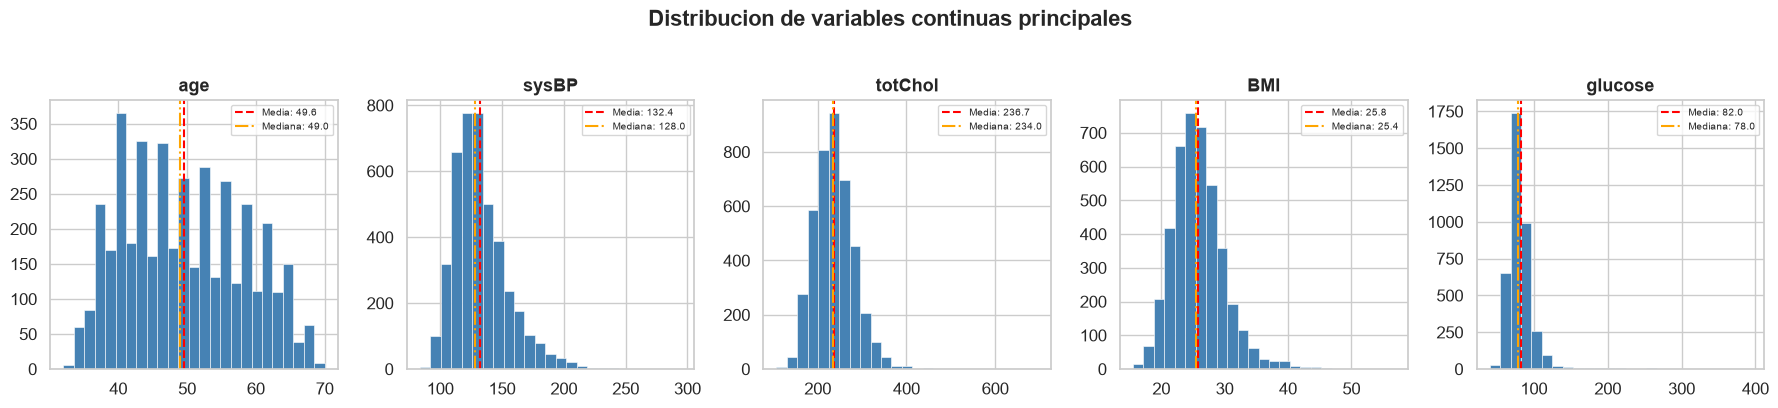

In [13]:
# Figura 1: Histogramas de variables continuas principales
vars_hist = ['age', 'sysBP', 'totChol', 'BMI', 'glucose']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, col in zip(axes, vars_hist):
    data = df[col].dropna()
    ax.hist(data, bins=25, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.axvline(data.mean(), color='red', lw=1.5, ls='--',
               label=f'Media: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', lw=1.5, ls='-.',
               label=f'Mediana: {data.median():.1f}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=7)

plt.suptitle('Distribucion de variables continuas principales', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/fig1_histogramas.pdf', bbox_inches='tight')
plt.show()


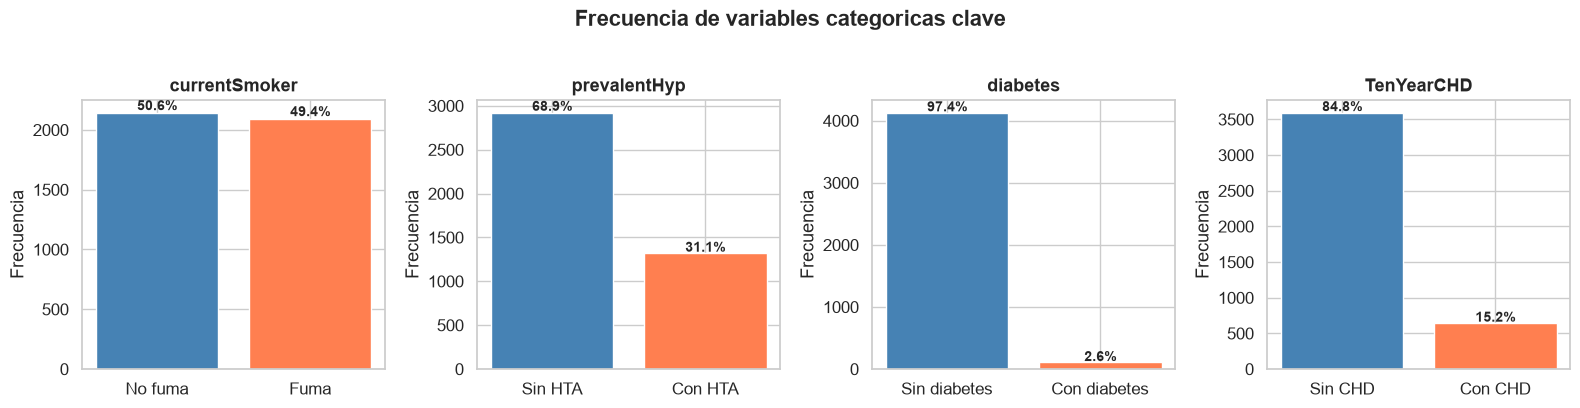

In [14]:
# Figura 2: Variables categoricas - frecuencias
vars_cat = ['currentSmoker', 'prevalentHyp', 'diabetes', 'TenYearCHD']
etiq_cat = {
    'currentSmoker': ['No fuma', 'Fuma'],
    'prevalentHyp':  ['Sin HTA', 'Con HTA'],
    'diabetes':      ['Sin diabetes', 'Con diabetes'],
    'TenYearCHD':    ['Sin CHD', 'Con CHD']
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, vars_cat):
    vc  = df[col].value_counts().sort_index()
    pct = df[col].value_counts(normalize=True).sort_index() * 100
    bars = ax.bar(etiq_cat[col], vc.values, color=['steelblue', 'coral'], edgecolor='white')
    for bar, p in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{p:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Frecuencia')

plt.suptitle('Frecuencia de variables categoricas clave', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/fig2_categoricas.pdf', bbox_inches='tight')
plt.show()

### Distribucion individual con KDE — variables clinicas clave

Visualizacion detallada de las tres variables con mayor correlacion con CHD.

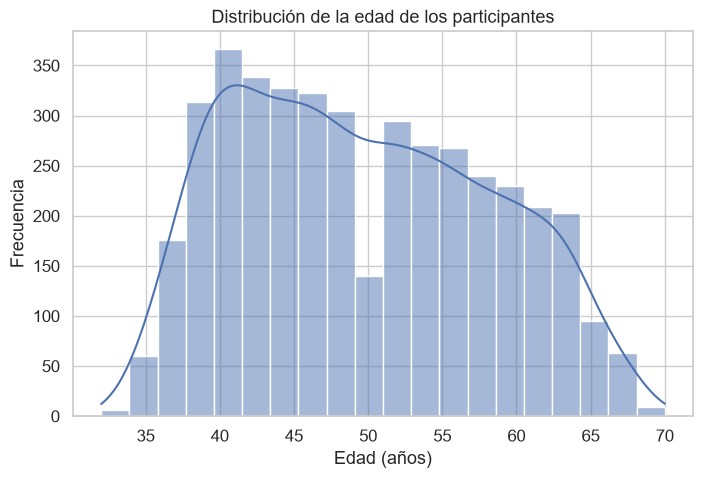

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)

plt.title("Distribución de la edad de los participantes")
plt.xlabel("Edad (años)")
plt.ylabel("Frecuencia")

plt.show()

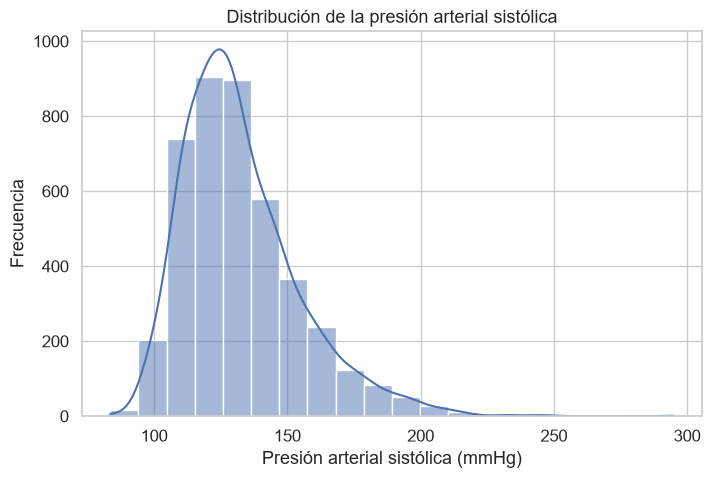

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['sysBP'], bins=20, kde=True)

plt.title("Distribución de la presión arterial sistólica")
plt.xlabel("Presión arterial sistólica (mmHg)")
plt.ylabel("Frecuencia")

plt.show()

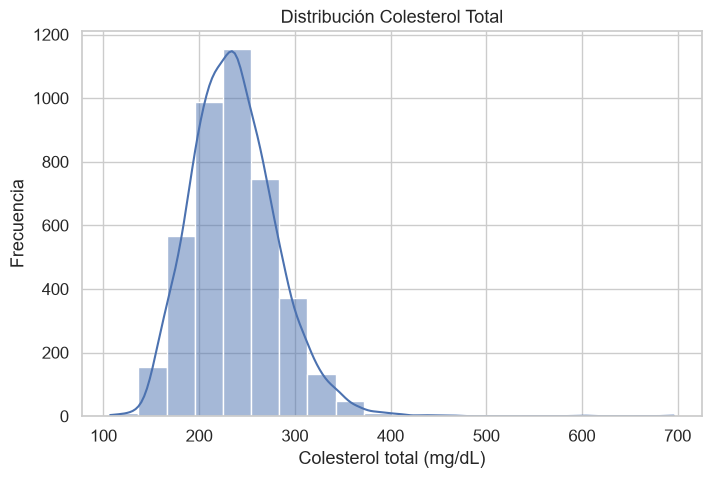

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['totChol'], bins=20, kde=True)

plt.title("Distribución Colesterol Total")
plt.xlabel("Colesterol total (mg/dL)")
plt.ylabel("Frecuencia")

plt.show()

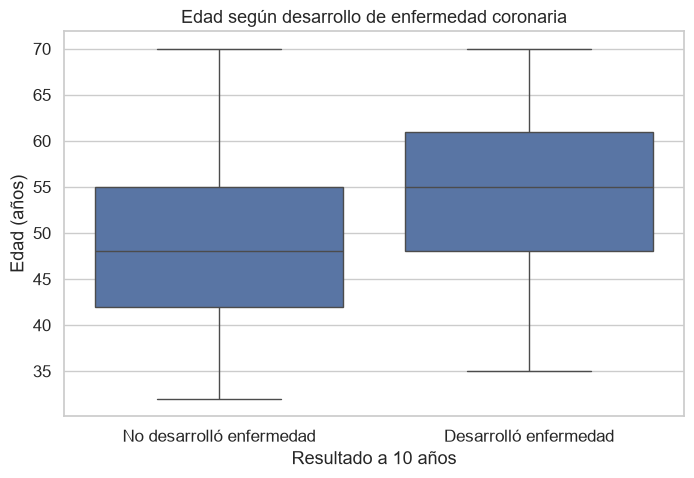

In [18]:
df["CHD_Label"] = df["TenYearCHD"].map({
    0: "No desarrolló enfermedad",
    1: "Desarrolló enfermedad"
})

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="CHD_Label",
    y="age"
)

plt.xlabel("Resultado a 10 años")
plt.ylabel("Edad (años)")
plt.title("Edad según desarrollo de enfermedad coronaria")

plt.show()

### Distribucion de participantes segun habito tabaquico


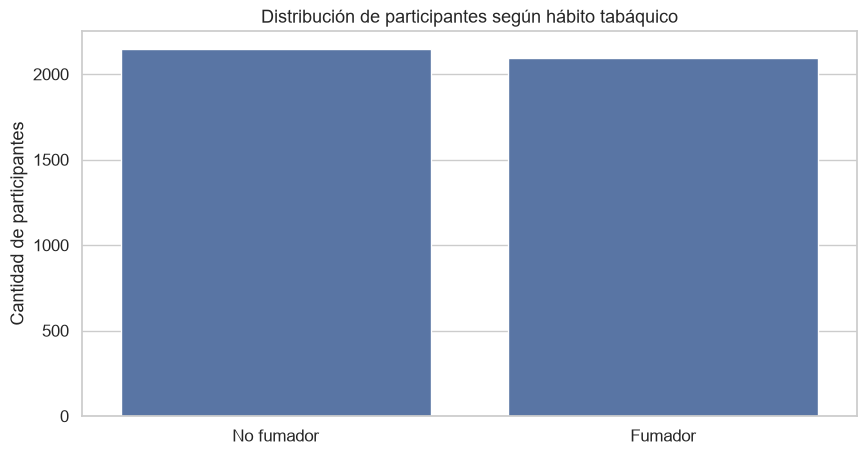

In [19]:
df["Smoker_Label"] = df["currentSmoker"].map({
    0: "No fumador",
    1: "Fumador"
})

sns.countplot(
    data=df,
    x="Smoker_Label"
)

plt.xlabel("")
plt.ylabel("Cantidad de participantes")
plt.title("Distribución de participantes según hábito tabáquico")

plt.show()

---
## 6. Relaciones preliminares entre variables

Se exploran relaciones entre pares de variables para identificar patrones relevantes antes de pasar al analisis inferencial (Fase 2).

Las herramientas usadas son:
- **Correlacion de Pearson**: entre variables cuantitativas
- **Boxplot comparativo**: variable cuantitativa vs categorica
- **Tabla de contingencia**: entre dos variables categoricas


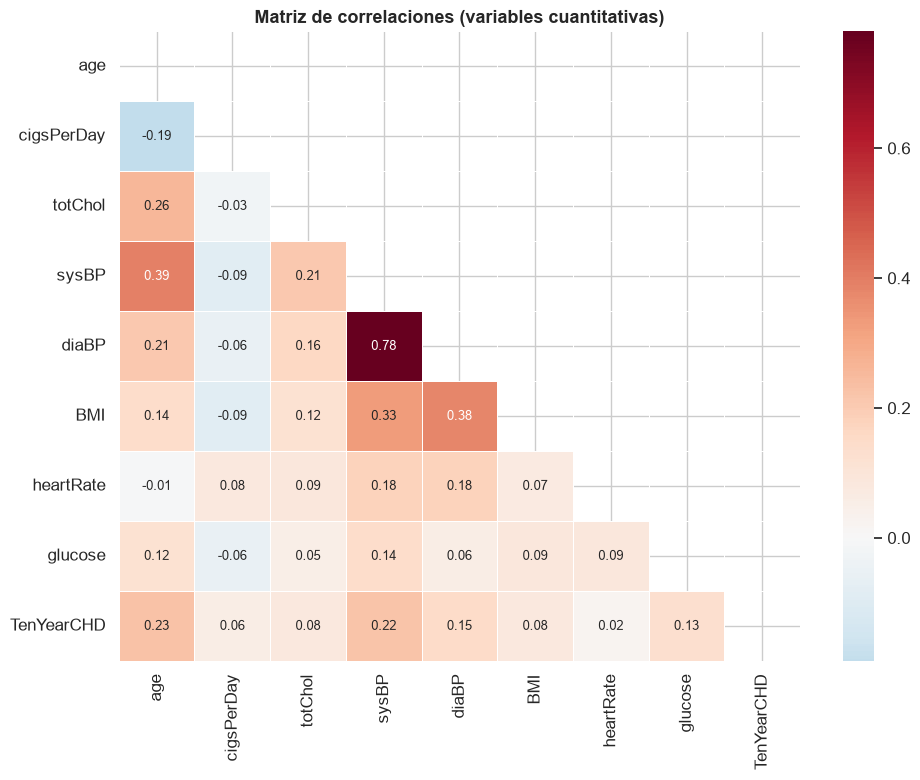

Correlacion de cada variable con TenYearCHD (de mayor a menor):
  age            : r = 0.230
  sysBP          : r = 0.220
  diaBP          : r = 0.150
  glucose        : r = 0.130
  BMI            : r = 0.080
  totChol        : r = 0.080
  cigsPerDay     : r = 0.060
  heartRate      : r = 0.020


In [20]:
# Figura 3: Mapa de correlacion entre variables cuantitativas
vars_corr = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP',
             'BMI', 'heartRate', 'glucose', 'TenYearCHD']

corr = df[vars_corr].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, ax=ax,
            annot_kws={'size': 9}, linewidths=0.5)
ax.set_title('Matriz de correlaciones (variables cuantitativas)', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/fig3_correlaciones.pdf', bbox_inches='tight')
plt.show()

# Top correlaciones con TenYearCHD
print('Correlacion de cada variable con TenYearCHD (de mayor a menor):')
top_corr = corr['TenYearCHD'].drop('TenYearCHD').sort_values(ascending=False)
for var, val in top_corr.items():
    print(f'  {var:15s}: r = {val:.3f}')


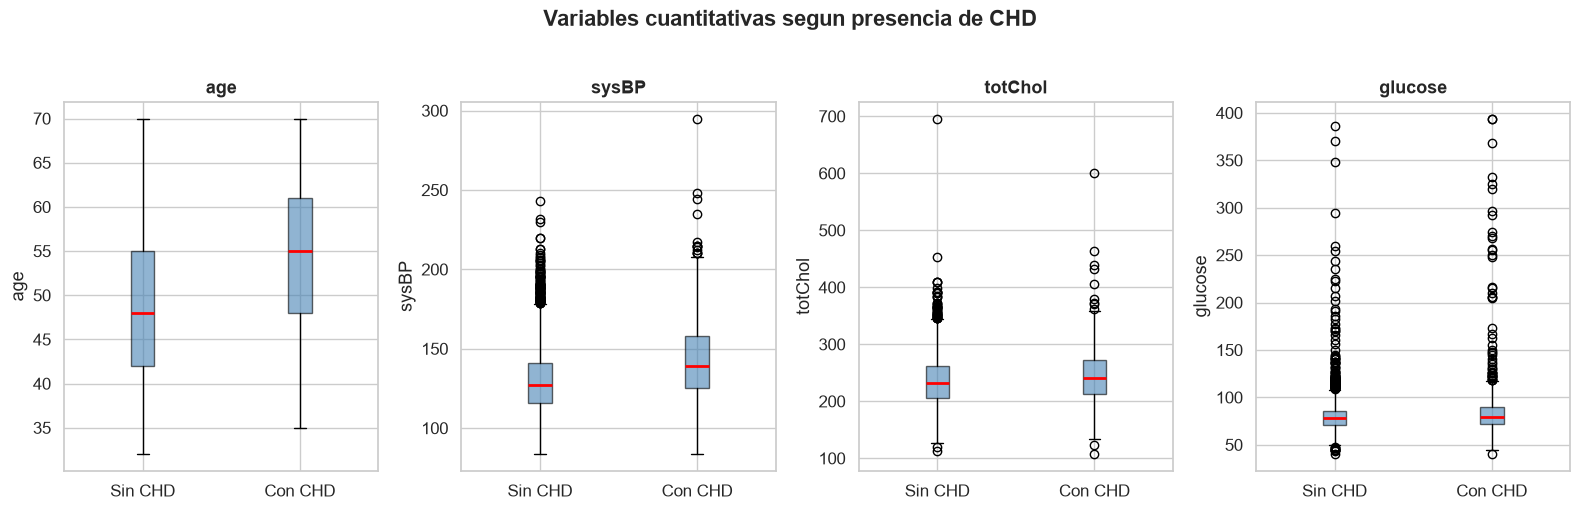

In [21]:
# Figura 4: Boxplot de variables clave por TenYearCHD
vars_box = ['age', 'sysBP', 'totChol', 'glucose']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, vars_box):
    data_0 = df[df['TenYearCHD'] == 0][col].dropna()
    data_1 = df[df['TenYearCHD'] == 1][col].dropna()
    ax.boxplot([data_0, data_1],
               tick_labels=['Sin CHD', 'Con CHD'],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Variables cuantitativas segun presencia de CHD', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/fig4_boxplot_chd.pdf', bbox_inches='tight')
plt.show()


In [22]:
# Tabla de contingencia: tabaquismo vs CHD
tabla = pd.crosstab(
    df['currentSmoker'],
    df['TenYearCHD'],
    rownames=['Fumador'],
    colnames=['CHD a 10 anyos'],
    margins=True
)
tabla.index = ['No fumador', 'Fumador', 'Total']
tabla.columns = ['Sin CHD', 'Con CHD', 'Total']

print('Tabla de contingencia: tabaquismo actual vs CHD a 10 anyos')
display(tabla)

# Porcentajes por fila
tabla_pct = pd.crosstab(
    df['currentSmoker'],
    df['TenYearCHD'],
    rownames=['Fumador'],
    colnames=['CHD a 10 anyos'],
    normalize='index'
) * 100
tabla_pct.index = ['No fumador', 'Fumador']
tabla_pct.columns = ['Sin CHD (%)', 'Con CHD (%)']
tabla_pct = tabla_pct.round(1)

print('\nPorcentaje por grupo:')
display(tabla_pct)


Tabla de contingencia: tabaquismo actual vs CHD a 10 anyos


,Sin CHD,Con CHD,Total
No fumador,1834,311,2145
Fumador,1762,333,2095
Total,3596,644,4240



Porcentaje por grupo:


,Sin CHD (%),Con CHD (%)
No fumador,85.5,14.5
Fumador,84.1,15.9


### Matriz de correlacion con nombres en español


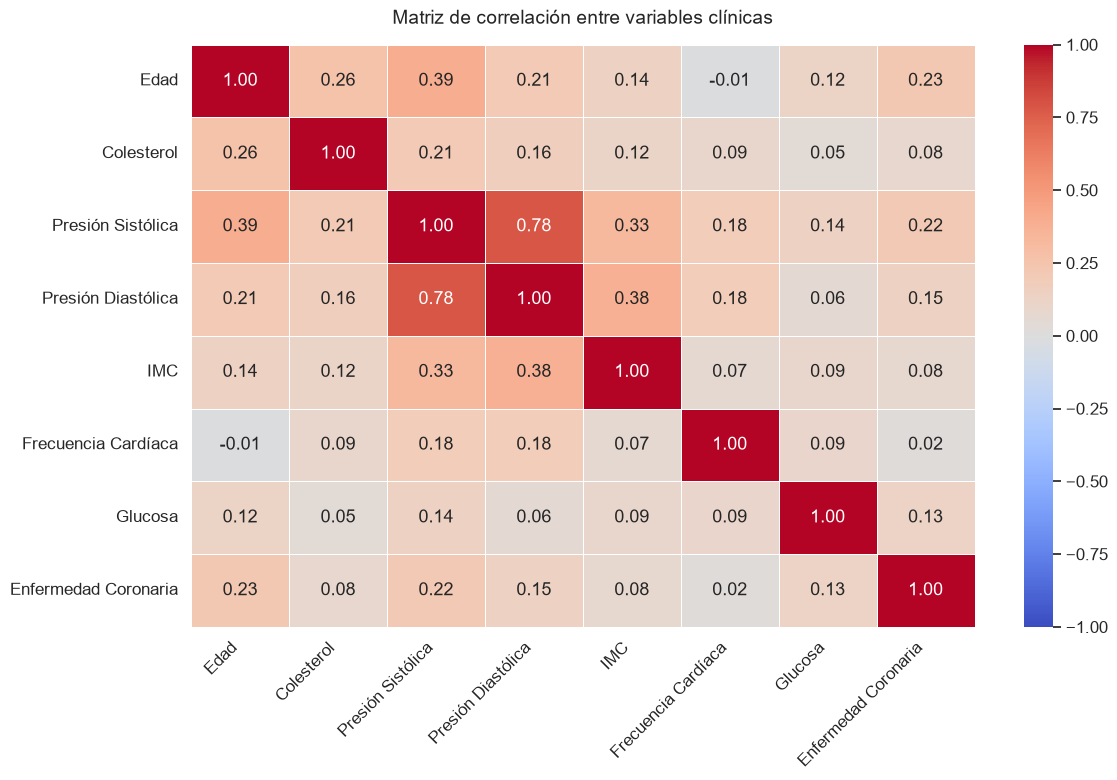

In [23]:
corr_df = df.rename(columns={
    "age": "Edad",
    "totChol": "Colesterol",
    "sysBP": "Presión Sistólica",
    "diaBP": "Presión Diastólica",
    "BMI": "IMC",
    "heartRate": "Frecuencia Cardíaca",
    "glucose": "Glucosa",
    "TenYearCHD": "Enfermedad Coronaria"
})

corr_variables = [
    "Edad",
    "Colesterol",
    "Presión Sistólica",
    "Presión Diastólica",
    "IMC",
    "Frecuencia Cardíaca",
    "Glucosa",
    "Enfermedad Coronaria"
]

corr_matrix = corr_df[corr_variables].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title(
    "Matriz de correlación entre variables clínicas",
    fontsize=14,
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

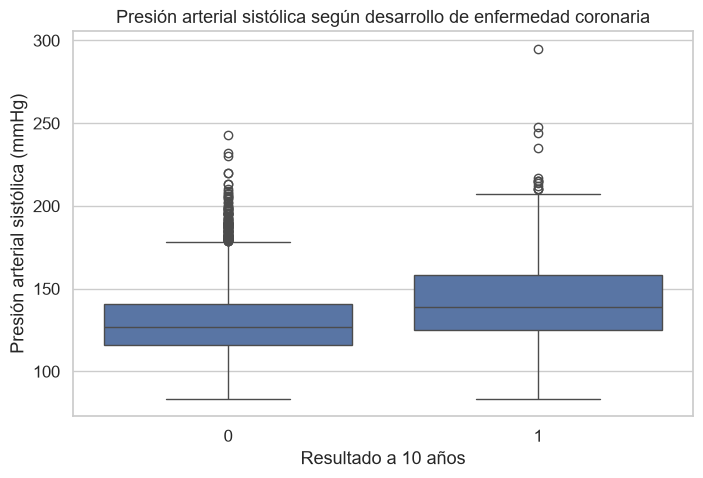

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='TenYearCHD',
    y='sysBP'
)

plt.title("Presión arterial sistólica según desarrollo de enfermedad coronaria")
plt.xlabel("Resultado a 10 años")
plt.ylabel("Presión arterial sistólica (mmHg)")

plt.show()

In [25]:
media_edad = df['age'].mean()

print("Edad promedio:")
print(round(media_edad,2))

Edad promedio:
49.58


In [26]:
confianza = 0.95

n = len(df)

media = df['age'].mean()

desv = stats.sem(df['age'])

ic = stats.t.interval(
    confianza,
    n-1,
    loc=media,
    scale=desv
)

print("IC 95% edad:")
print(ic)

IC 95% edad:
(np.float64(49.322070211324395), np.float64(49.83830714716617))


In [27]:
p = df['TenYearCHD'].mean()

print("Proporción:")
print(round(p,4))

Proporción:
0.1519


In [28]:
casos = df['TenYearCHD'].sum()

total = len(df)

ic_prop = proportion_confint(
    casos,
    total,
    alpha=0.05,
    method='wilson'
)

print("IC 95% proporción enfermedad coronaria")
print(ic_prop)

IC 95% proporción enfermedad coronaria
(0.1413990013492756, 0.16300479680290123)


In [29]:
grupo0 = df[df['TenYearCHD']==0]['age']

grupo1 = df[df['TenYearCHD']==1]['age']

t_stat, p_value = ttest_ind(
    grupo0,
    grupo1,
    equal_var=False
)

print("Estadístico t:")
print(t_stat)

print("p-value:")
print(p_value)

Estadístico t:
-15.592302015443744
p-value:
8.605386624499929e-49


In [30]:
alpha = 0.05

if p_value < alpha:
    print("Se rechaza H0")
    print("Existe diferencia significativa en la edad.")
else:
    print("No se rechaza H0")

Se rechaza H0
Existe diferencia significativa en la edad.


In [31]:
tabla = pd.crosstab(
    df['currentSmoker'],
    df['TenYearCHD']
)

tabla

TenYearCHD,0,1
currentSmoker,,
0,1834,311
1,1762,333


In [32]:
chi2, p, dof, expected = chi2_contingency(tabla)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 1.4972035438574873
p-value: 0.2211021442164888


In [33]:
if p < 0.05:
    print("Existe asociación entre fumar y enfermedad coronaria.")
else:
    print("No existe evidencia suficiente de asociación.")

No existe evidencia suficiente de asociación.


---
## 7. Sintesis de hallazgos preliminares

Esta seccion resume las observaciones identificadas en la exploracion inicial. No se realizan inferencias estadisticas formales — eso corresponde a la Fase 2.


In [34]:
print('SINTESIS DE HALLAZGOS PRELIMINARES')
print('=' * 55)
print()
print('Dataset:')
print(f'  {df.shape[0]:,} pacientes, {df.shape[1]} variables')
print(f'  7 variables cuantitativas | 9 variables cualitativas')
print(f'  Faltantes naturales en 7 variables (max: glucose 9.2%)')
print()
print('Variable objetivo:')
chd_pct = df['TenYearCHD'].mean() * 100
print(f'  TenYearCHD = 1: {chd_pct:.1f}% de la muestra')
print(f'  Clases desbalanceadas -> a considerar en Fase 3')
print()
print('Relaciones preliminares identificadas:')
print('  - age y sysBP son las variables con mayor correlacion')
print(f'    con CHD (r=0.23 y r=0.22 respectivamente)')
print('  - Los pacientes con CHD muestran mayor edad,')
print('    presion sistolica y glucosa (visible en boxplots)')
print('  - No se observa diferencia clara entre fumadores')
print('    y no fumadores en prevalencia de CHD bruta')
print()
print('Proximos pasos (Fase 2 - Sumativa 1):')
print('  - Calcular intervalos de confianza (ID1.3)')
print('  - Aplicar pruebas de hipotesis formales (ID1.4)')
print('  - Modelo de regresion logistica (Fase 3)')


SINTESIS DE HALLAZGOS PRELIMINARES

Dataset:
  4,240 pacientes, 18 variables
  7 variables cuantitativas | 9 variables cualitativas
  Faltantes naturales en 7 variables (max: glucose 9.2%)

Variable objetivo:
  TenYearCHD = 1: 15.2% de la muestra
  Clases desbalanceadas -> a considerar en Fase 3

Relaciones preliminares identificadas:
  - age y sysBP son las variables con mayor correlacion
    con CHD (r=0.23 y r=0.22 respectivamente)
  - Los pacientes con CHD muestran mayor edad,
    presion sistolica y glucosa (visible en boxplots)
  - No se observa diferencia clara entre fumadores
    y no fumadores en prevalencia de CHD bruta

Proximos pasos (Fase 2 - Sumativa 1):
  - Calcular intervalos de confianza (ID1.3)
  - Aplicar pruebas de hipotesis formales (ID1.4)
  - Modelo de regresion logistica (Fase 3)
